# <h1 align="center"> Filragem de SSRs utilizando HipSTR e MISA orientado por genoma de ref. em *Dipteryx alata* Vogel.

## <h2 align="justify"><span style="color: blue;">Esse script foi desenvolvido no contexto da dissertação de mestrado do aluno: Artur Gabriel Rodrigues Silva, no programa de pós graduação em Genética e Melhoramento de Plantas UFG (2025-2026), sob a orientação da professora Thannya Nascimento Soares, e coorientação de Marco Aurélio Caldas de Pinho Pessoa Filho da Embrapa Recursos Genéticos e Biotecnologia, e Rhewter Nunes da Universidade Estadual de Goiás.</span>

## Descrição do projeto

<h3 align="justify">A amostragem será composta por 24 populações de Dipteryx alata Vogel. representadas por um indivíduo cada, sequenciados em lcWGS (9x~14x). As populações são pertencentes ao banco de germoplasma da UFG. Os dados de sequenciamento foram obtidos a partir de outros projetos realizados anteriormente, o sequenciamento foi realizado em Illumina NextSeq 1000, no Laboratório de Imunologia de Transplantes de Goiás (HLAGyn), o cartucho foi identificado como “NextSeq P2 600 ciclos”, a estimativa era de gerar 800 milhões de reads paired-end no total, que dividindo por 24 indivíduos esperava-se 33,33 milhões de reads por amostra, outra estimativa esperada era de gerar 240 Gb de dados, que dividindo pelo número de indivíduos esperava-se 10 Gb por amostra. O genoma de referência está montado em 8 cromossomos e 57 contigs.

---

# 1. Criando seu ambiente Docker
Um ambiente docker é um "espaço" isolado dentro do servidor, de forma que as instalações realizadas nele não afetem o restante do servidor, permitindo utilizar diferentes versões de diferentes ferramentas (crie antes um Tmux para rodar o Docker dentro do Tmux)

Baixando a Imagem do HipSTR

In [ ]:
%%bash

docker pull weisburd/hipstr

In [ ]:
%%bash

docker run \
  -it \
  -v /media/lgbio-nas1/artur.silva/data/projects/baru:/hipstr/my_data weisburd/hipstr

---

# 2. Instalação de dependências
Atualizando pacotes disponíveis, instalando os seguintes pacotes sem pedir confirmação

In [ ]:
%% bash

cd /hipstr/my_data

apt-get update && apt-get install -y \
  git wget curl unzip make g++ python3 python3-pip fastqc fastp \
  samtools bcftools tabix parallel nano less bedtools perl bzip2

In [ ]:
%%bash

wget https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh \
    -O miniconda.sh && \
    bash miniconda.sh -b -p /opt/conda && \
    rm miniconda.sh
PATH="/opt/conda/bin:${PATH}"

---

# 3. Descoberta de SSRs (Tandem Repeat Finder)

"A tandem repeat in DNA is two or more adjacent, approximate copies of a pattern of nucleotides. Tandem Repeats Finder is a program to locate and display tandem repeats in DNA sequences. In order to use the program, the user submits a sequence in FASTA format. There is no need to specify the pattern, the size of the pattern or any other parameter. The output consists of two files: a repeat table file and an alignment file. The repeat table, viewable in a web browser, contains information about each repeat, including its location, size, number of copies and nucleotide content."

https://github.com/Benson-Genomics-Lab/TRF

In [ ]:
%%bash

conda install bioconda::trf

## The alignment weights for:
- `matching (Match)` equal to 2,
- `mismatching (Mismatch)` penalty is 5,
- `indel (Delta)` penalty is 7,
- `the match probability (PM)` is 80,
- `the indel probability (PI)` is 10,
- `the minimum alignment score (Minscore)` is 50,
- `the maximum period size (MaxPeriod)` (the pattern size of the tandem repeat) to report is 500bp.
- `-d` (data file)
- `-h` (suppress html output)
- `-l` (maximum TR length expected (in millions) (eg, -l 3 or -l=3 for 3 million))

In [ ]:
%%bash
#Gerar saída compacta NGS com flancos de 50bp
trf \
    genome.fasta 2 5 7 80 10 50 500 \
    -ngs -h -l 1 > genome.trf.dat

_O output é dado no seguinte formato:_
| Coluna | Significado     |
| ------ | --------------- |
| 1      | Start           |
| 2      | End             |
| 3      | **Period size** |
| 4      | **Copy number** |
| 5      | Consensus size  |
| 6      | % matches       |
| 7      | % indels        |
| 8      | Alignment score |
| 9      | A               |
| 10     | C               |
| 11     | G               |
| 12     | T               |
| 13     | Entropy         |

## Foram realizadas etapas adicionais de pós-processamento dos arquivos de saída do TRF, consistentes na remoção de STRs e na conversão para o formato BED:
- (i) `with overlapping STRs`,
- (ii) `with motif period size` > 9bp,
- (iii) `repeat number of the motif` < 3, (número de cópias)
- (iv) `where the percent of matches` <= 85%,
- (v) `where the per centage of indels` >= 5%,
- (vi) `the repeat length was larger than 70bp`, as the genotype call rate declined for longer tandem repeats.

#### Transformar .dat em .tsv

In [ ]:
%%bash

INPUT_FILE="genome.trf.dat"

echo "Step 1: Converting .dat to TSV format..."

awk '
BEGIN { OFS="\t" }
/^@Dal_0/ {
  chr = substr($0, 2)
  next
}
$1 ~ /^[0-9]+$/ {
  print chr, $1, $2, $3, $4, $6, $7, $13
}
' "$INPUT_FILE" > str_raw2.tsv

echo "  Created: str_raw2.tsv"
echo "  Total STRs extracted: $(wc -l < str_raw2.tsv)"
echo ""

`464.385` Regiões repetitivas descobertas

#### Filtros do artigo de plasmodium

In [ ]:
%%bash

echo "Step 2: Applying quality filters..."

awk -F'\t' 'BEGIN{OFS="\t"}
{
  len = $3 - $2 + 1
  if ($4 <= 9 && $5 >= 3 && $6 >= 85 && $7 <= 5 && len <= 70)
    print
}' str_raw2.tsv > str_filtered2.tsv

echo "  Created: str_filtered2.tsv"
echo "  STRs after filtering: $(wc -l < str_filtered2.tsv)"
echo "  STRs removed: $(($(wc -l < str_raw2.tsv) - $(wc -l < str_filtered2.tsv)))"
echo ""

#### Etapa de ordenação por cromossomo e posição

In [ ]:
%%bash

echo "Step 3: Sorting by chromosome and position..."

sort -k1,1 -k2,2n str_filtered2.tsv > str_filtered.sorted2.tsv

echo "  Created: str_filtered.sorted2.tsv"
echo ""

#### Remover STRs sobrepostos

In [ ]:
%%bash

echo "Step 4: Removing overlapping STRs..."

awk -F'\t' 'BEGIN{OFS="\t"}
NR==1 {
  chr=$1; start=$2; end=$3
  print
  next
}
{
  if ($1==chr && $2<=end) {
    if ($3>end) end=$3
    next
  } else {
    chr=$1; start=$2; end=$3
    print
  }
}' str_filtered.sorted2.tsv > str_final2.tsv

echo "  Created: str_final2.tsv"
echo "  Non-overlapping STRs: $(wc -l < str_final2.tsv)"
echo "  Overlapping STRs removed: $(($(wc -l < str_filtered.sorted2.tsv) - $(wc -l < str_final2.tsv)))"
echo ""
echo "  *** Use str_final.tsv for STR discovery statistics ***"
echo ""

`Configuração do arquivo:` chr | start | end | period_size | copy_number | %matches | %indels | entropy

#### Converter para BED

In [ ]:
%%bash

echo "Step 5: Converting to BED format..."

awk -F'\t' 'BEGIN{OFS="\t"}
{
  name = $1":"$2"-"$3
  print $1, $2-1, $3, $4, $5, name
}' str_final.tsv > hipstr_input.bed

echo "=========================================="
echo "Pipeline Complete!"
echo "=========================================="
echo ""
echo "Summary of STR filtering:"
echo "  Raw STRs extracted:     $(wc -l < str_raw.tsv)"
echo "  After quality filters:  $(wc -l < str_filtered.tsv)"
echo "  After overlap removal:  $(wc -l < str_final.tsv)"
echo ""

`Summary of STR filtering:`
- `Raw STRs extracted:`     464.385
- `After quality filters:`  34.635
- `After overlap removal:`  33.746

Configuração do arquivo: chr | start(0-based) | end | period_size | copy_number | name

In [ ]:
%%bash

awk -F'\t' '
NR>1 {
  len = $3 - $2
  if (NR==2 || len<minlen) minlen=len
  if (len>maxlen) maxlen=len
  if (NR==2 || $4<minperiod) minperiod=$4
  if ($4>maxperiod) maxperiod=$4
  if (NR==2 || $5<mincopy) mincopy=$5
  if ($5>maxcopy) maxcopy=$5
}
END {
  print "Comprimento — min:", minlen, "max:", maxlen
  print "Period size — min:", minperiod, "max:", maxperiod
  print "Copy number — min:", mincopy, "max:", maxcopy
}' hipstr_input.bed

- Comprimento — min: 25 max: 70
- Period size — min: 1 max: 9
- Copy number — min: 3.0 max: 67.0

## 3.1 Gerando dados descritivos da descoberta de SSRs

### Extraindo tamanho do genoma

In [ ]:
awk '{sum+=$2} END {print sum}' genome.fasta.fai

`702445685 bp`

### Histograma de entropia

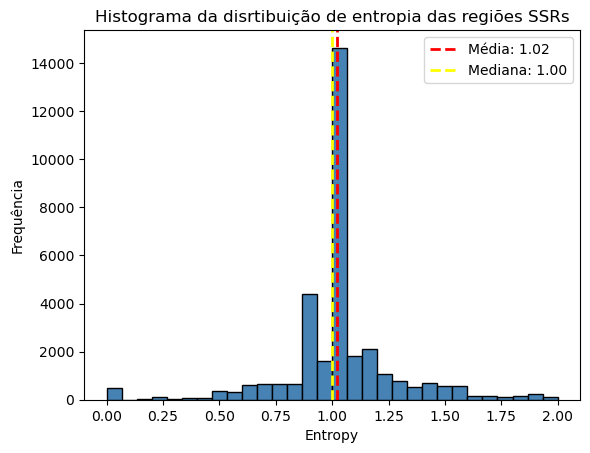

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Ler o arquivo .dat (sem cabeçalho)
dados = pd.read_csv("str_final2.tsv", sep="\t", header=None) 

# Selecionar a coluna pelo índice (exemplo: coluna 2 → índice 1)
coluna = dados.iloc[:, 7]

# Calcular média e mediana
media = coluna.mean()
mediana = coluna.median()

# Adicionar linhas de média e mediana
plt.axvline(media, color='red', linestyle='dashed', linewidth=2, label=f'Média: {media:.2f}')
plt.axvline(mediana, color='yellow', linestyle='dashed', linewidth=2, label=f'Mediana: {mediana:.2f}')

# Plotar o histograma
plt.hist(coluna, bins=30, color='steelblue', edgecolor='black')
plt.xlabel("Entropy")
plt.ylabel("Frequência")
plt.title("Histograma da disrtibuição de entropia das regiões SSRs")
plt.legend()
plt.show()

### Caracterização das regiões SSRs

Rode o script R abaixo para gerar:
- `Tabela com os dados de cromossomo por motif`
- `Total chromosomes analyzed:` 8
- `Total chromosome size:` 698,801,365 bp (698.80 Mb)
- `Total SSRs found:` 33,746
- `Average SSRs per Mb:` 48.29
- `Total SSR length:` 1,287,892 bp
- `Percentage of genome in SSRs:` 0.1843%
- `Gráfico de pizza da distribuição`
- `Gráfico: Mapa físico da distribuição dos motif nos cromossomos e sua versão heatmap`
- `Boxplot do motivo de repetição por comprimento do microssatélite em pb`

### Análises R realizadas com o script: `chr_trf_script1.Rmd`

---

# 4. Pré-processamento dos dados de sequenciamento

## 4.1 Controle de qualidade

Execute o fastQC para verificar a qualidade dos dados de sequenciamento para cortes se necessario

In [ ]:
%%bash

fastqc \
  ../sequencing/*fastq.gz \
  -o .

## 4.2 Trimmagem

Remoção de adaptadores Illumina (Obs.: a ferramenta fastp é exclusivo para dados Illumina)

In [ ]:
%%bash

for R1 in ../sequencing/fastq/*_R1_001.fastq.gz; do
    SAMPLE=$(basename "$R1" _R1_001.fastq.gz)
    R2="../sequencing/fastq/${SAMPLE}_R2_001.fastq.gz"
    fastp \
        -i "$R1" \
        -I "$R2" \
        -o "${SAMPLE}_R1_001.trim.fq.gz" \
        -O "${SAMPLE}_R2_001.trim.fq.gz" \
        --detect_adapter_for_pe \
        -h "${SAMPLE}.fastp.html" \
        -q 20 \
        -w 16
done

Indexando genoma para alinhamento

In [ ]:
%%bash

conda install -c conda-forge -c bioconda bwa-mem2

In [ ]:
%%bash

bwa-mem2 index genome.fasta

## 4.3 Mapeamento a referência [arquivos SAM]
Os seus dados de sequenciamento bruto serão alinhados à referência utilizando o a ferramenta bwa-mem2, ela atribuirá a cada read a coordenada em relação ao genoma de referencia

Para além disso também são adicionados os metadados das amostras: Read Group, Amostra biológica, Biblioteca, Plataforma, Centro de sequenciamento, Data da corrida.

In [ ]:
%%bash

bwa-mem2 mem \
    -t 16 \
    -R "@RG\tID:A01\tSM:DalCGUFG_3.14\tLB:Genomas_Baru_UFGO\tPU:AACWW3FM5\tPL:illumina\tCN:HLAGyn\tDT:2023-01-25" \
    genome.fasta \
    A01*R1_001.trim.fq.gz \
    A01*R2_001.trim.fq.gz \
    > A01.sam

bwa-mem2 mem \
    -t 16 \
    -R "@RG\tID:A03\tSM:DalCGUFG_7.38\tLB:Genomas_Baru_UFGO\tPU:AACWW3FM5\tPL:illumina\tCN:HLAGyn\tDT:2023-01-25" \
    genome.fasta \
    A03*R1_001.trim.fq.gz \
    A03*R2_001.trim.fq.gz \
    > A03.sam

bwa-mem2 mem \
    -t 16 \
    -R "@RG\tID:A04\tSM:DalCGUFG_1.2Rep\tLB:Genomas_Baru_UFGO\tPU:AACWW3FM5\tPL:illumina\tCN:HLAGyn\tDT:2023-01-25" \
    genome.fasta \
    A04*R1_001.trim.fq.gz \
    A04*R2_001.trim.fq.gz \
    > A04.sam

bwa-mem2 mem \
    -t 16 \
    -R "@RG\tID:B02\tSM:DalCGUFG_4.22\tLB:Genomas_Baru_UFGO\tPU:AACWW3FM5\tPL:illumina\tCN:HLAGyn\tDT:2023-01-25" \
    genome.fasta \
    B02*R1_001.trim.fq.gz \
    B02*R2_001.trim.fq.gz \
    > B02.sam

bwa-mem2 mem \
    -t 16 \
    -R "@RG\tID:B03\tSM:DalCGUFG_8.44\tLB:Genomas_Baru_UFGO\tPU:AACWW3FM5\tPL:illumina\tCN:HLAGyn\tDT:2023-01-25" \
    genome.fasta \
    B03*R1_001.trim.fq.gz \
    B03*R2_001.trim.fq.gz \
    > B03.sam

bwa-mem2 mem \
    -t 16 \
    -R "@RG\tID:B04\tSM:DalCGUFG_10.55Rep\tLB:Genomas_Baru_UFGO\tPU:AACWW3FM5\tPL:illumina\tCN:HLAGyn\tDT:2023-01-25" \
    genome.fasta \
    B04*R1_001.trim.fq.gz \
    B04*R2_001.trim.fq.gz \
    > B04.sam

bwa-mem2 mem \
    -t 16 \
    -R "@RG\tID:C01\tSM:DalCGUFG_16.94\tLB:Genomas_Baru_UFGO\tPU:AACWW3FM5\tPL:illumina\tCN:HLAGyn\tDT:2023-01-25" \
    genome.fasta \
    C01*R1_001.trim.fq.gz \
    C01*R2_001.trim.fq.gz \
    > C01.sam

bwa-mem2 mem \
    -t 16 \
    -R "@RG\tID:C02\tSM:DalCGUFG_2.7\tLB:Genomas_Baru_UFGO\tPU:AACWW3FM5\tPL:illumina\tCN:HLAGyn\tDT:2023-01-25" \
    genome.fasta \
    C02*R1_001.trim.fq.gz \
    C02*R2_001.trim.fq.gz \
    > C02.sam

bwa-mem2 mem \
    -t 16 \
    -R "@RG\tID:C03\tSM:DalCGUFG_20.117\tLB:Genomas_Baru_UFGO\tPU:AACWW3FM5\tPL:illumina\tCN:HLAGyn\tDT:2023-01-25" \
    genome.fasta \
    C03*R1_001.trim.fq.gz \
    C03*R2_001.trim.fq.gz \
    > C03.sam

bwa-mem2 mem \
    -t 16 \
    -R "@RG\tID:D01\tSM:DalCGUFG_23.136\tLB:Genomas_Baru_UFGO\tPU:AACWW3FM5\tPL:illumina\tCN:HLAGyn\tDT:2023-01-25" \
    genome.fasta \
    D01*R1_001.trim.fq.gz \
    D01*R2_001.trim.fq.gz \
    > D01.sam

bwa-mem2 mem \
    -t 16 \
    -R "@RG\tID:D02\tSM:DalCGUFG_14.80\tLB:Genomas_Baru_UFGO\tPU:AACWW3FM5\tPL:illumina\tCN:HLAGyn\tDT:2023-01-25" \
    genome.fasta \
    D02*R1_001.trim.fq.gz \
    D02*R2_001.trim.fq.gz \
    > D02.sam

bwa-mem2 mem \
    -t 16 \
    -R "@RG\tID:D03\tSM:DalCGUFG_19.133\tLB:Genomas_Baru_UFGO\tPU:AACWW3FM5\tPL:illumina\tCN:HLAGyn\tDT:2023-01-25" \
    genome.fasta \
    D03*R1_001.trim.fq.gz \
    D03*R2_001.trim.fq.gz \
    > D03.sam

bwa-mem2 mem \
    -t 16 \
    -R "@RG\tID:E01\tSM:DalCGUFG_22.127\tLB:Genomas_Baru_UFGO\tPU:AACWW3FM5\tPL:illumina\tCN:HLAGyn\tDT:2023-01-25" \
    genome.fasta \
    E01*R1_001.trim.fq.gz \
    E01*R2_001.trim.fq.gz \
    > E01.sam

bwa-mem2 mem \
    -t 16 \
    -R "@RG\tID:E02\tSM:DalCGUFG_17.98\tLB:Genomas_Baru_UFGO\tPU:AACWW3FM5\tPL:illumina\tCN:HLAGyn\tDT:2023-01-25" \
    genome.fasta \
    E02*R1_001.trim.fq.gz \
    E02*R2_001.trim.fq.gz \
    > E02.sam

bwa-mem2 mem \
    -t 16 \
    -R "@RG\tID:E03\tSM:DalCGUFG_18.105\tLB:Genomas_Baru_UFGO\tPU:AACWW3FM5\tPL:illumina\tCN:HLAGyn\tDT:2023-01-25" \
    genome.fasta \
    E03*R1_001.trim.fq.gz \
    E03*R2_001.trim.fq.gz \
    > E03.sam

bwa-mem2 mem \
    -t 16 \
    -R "@RG\tID:F01\tSM:DalCGUFG_15.88\tLB:Genomas_Baru_UFGO\tPU:AACWW3FM5\tPL:illumina\tCN:HLAGyn\tDT:2023-01-25" \
    genome.fasta \
    F01*R1_001.trim.fq.gz \
    F01*R2_001.trim.fq.gz \
    > F01.sam

bwa-mem2 mem \
    -t 16 \
    -R "@RG\tID:F02\tSM:DalCGUFG_13.73\tLB:Genomas_Baru_UFGO\tPU:AACWW3FM5\tPL:illumina\tCN:HLAGyn\tDT:2023-01-25" \
    genome.fasta \
    F02*R1_001.trim.fq.gz \
    F02*R2_001.trim.fq.gz \
    > F02.sam

bwa-mem2 mem \
    -t 16 \
    -R "@RG\tID:F03\tSM:DalCGUFG_5.26\tLB:Genomas_Baru_UFGO\tPU:AACWW3FM5\tPL:illumina\tCN:HLAGyn\tDT:2023-01-25" \
    genome.fasta \
    F03*R1_001.trim.fq.gz \
    F03*R2_001.trim.fq.gz \
    > F03.sam

bwa-mem2 mem \
    -t 16 \
    -R "@RG\tID:G01\tSM:DalCGUFG_6.34\tLB:Genomas_Baru_UFGO\tPU:AACWW3FM5\tPL:illumina\tCN:HLAGyn\tDT:2023-01-25" \
    genome.fasta \
    G01*R1_001.trim.fq.gz \
    G01*R2_001.trim.fq.gz \
    > G01.sam

bwa-mem2 mem \
    -t 16 \
    -R "@RG\tID:G02\tSM:DalCGUFG_11.66\tLB:Genomas_Baru_UFGO\tPU:AACWW3FM5\tPL:illumina\tCN:HLAGyn\tDT:2023-01-25" \
    genome.fasta \
    G02*R1_001.trim.fq.gz \
    G02*R2_001.trim.fq.gz \
    > G02.sam

bwa-mem2 mem \
    -t 16 \
    -R "@RG\tID:G03\tSM:DalCGUFG_25.147\tLB:Genomas_Baru_UFGO\tPU:AACWW3FM5\tPL:illumina\tCN:HLAGyn\tDT:2023-01-25" \
    genome.fasta \
    G03*R1_001.trim.fq.gz \
    G03*R2_001.trim.fq.gz \
    > G03.sam

bwa-mem2 mem \
    -t 16 \
    -R "@RG\tID:H01\tSM:DalCGUFG_21.121\tLB:Genomas_Baru_UFGO\tPU:AACWW3FM5\tPL:illumina\tCN:HLAGyn\tDT:2023-01-25" \
    genome.fasta \
    H01*R1_001.trim.fq.gz \
    H01*R2_001.trim.fq.gz \
    > H01.sam

bwa-mem2 mem \
    -t 16 \
    -R "@RG\tID:H02\tSM:DalCGUFG_12.67\tLB:Genomas_Baru_UFGO\tPU:AACWW3FM5\tPL:illumina\tCN:HLAGyn\tDT:2023-01-25" \
    genome.fasta \
    H02*R1_001.trim.fq.gz \
    H02*R2_001.trim.fq.gz \
    > H02.sam

bwa-mem2 mem \
    -t 16 \
    -R "@RG\tID:H03\tSM:DalCGUFG_9.50\tLB:Genomas_Baru_UFGO\tPU:AACWW3FM5\tPL:illumina\tCN:HLAGyn\tDT:2023-01-25" \
    genome.fasta \
    H03*R1_001.trim.fq.gz \
    H03*R2_001.trim.fq.gz \
    > H03.sam

## 4.4 Sort [Arquivos sorted.bam alinhados e ordenados]
Apesar das coordenadas dos reads terem sido atribuídas, é necessário ordenar os reads em relação à referência

In [ ]:
%%bash

for SAM in *.sam; do
    SAMPLE=$(basename "$SAM" .sam)
    samtools view -bS "$SAM" | samtools sort -@ 16 -o "${SAMPLE}.sorted.bam"
done

## 4.5 Marcando duplicatas e indexando
Por fim, é realizado a etapa de marcação de possíveis duplicatas de PCR oriundas do preparo da biblioteca de sequenciamento, seguido da indexação dos arquivos dedup.

In [ ]:
%%bash

conda install bioconda::picard

In [ ]:
%%bash

for bam in *.sorted.bam; do
    base=${bam%.sorted.bam}
    picard MarkDuplicates \
        I="$bam" \
        O="${base}.dedup.bam" \
        M="${base}.metrics.txt" \
        REMOVE_DUPLICATES=false
    samtools index "${base}.dedup.bam"
done

---

# 5. HipSTR

O HipSTR foi desenvolvido especificamente para lidar com os erros associados à genotipagem de repetições curtas em tandem (STRs), com o objetivo de obter genótipos mais robustos e confiáveis. Para isso, a ferramenta emprega uma série de estratégias avançadas, incluindo o aprendizado de modelos de stutter específicos para cada locus por meio de um algoritmo de Expectation-Maximization (EM), a identificação de alelos candidatos de STRs a partir de dados de sequenciamento em escala populacional, o uso de um modelo oculto de Markov especializado para alinhar as leituras aos alelos candidatos levando em conta os artefatos típicos de STRs, e a utilização de haplótipos de SNPs previamente faseados para realizar a genotipagem e a fase dos STRs. Em conjunto, esses elementos tornam o HipSTR, na opinião dos autores, a ferramenta mais confiável disponível para genotipagem de STRs a partir de dados de sequenciamento gerados por plataformas Illumina

Crie um índice para o genoma para rápida leitura

In [ ]:
%%bash

samtools faidx genome.fasta

***Executando HipSTR***

O HipSTR possui uma variedade de opções de uso projetadas para acomodar diferentes cenários em que os dados de sequenciamento variam quanto ao número de amostras e à profundidade de cobertura. Isso permite que a ferramenta seja aplicada de forma flexível em estudos genéticos com diferentes escalas e níveis de complexidade, garantindo resultados robustos mesmo em condições de dados heterogêneos:
- ***Mode 1: De novo stutter estimation + STR calling with de novo allele generation
This mode is identical to the one suggested in the Quick Start section as it suits most applications. HipSTR will output the STR genotypes in bgzipped VCF format to str_calls.vcf.gz***

In [ ]:
%%bash

HipSTR \
  --bams A01.dedup.bam,A03.dedup.bam,A04.dedup.bam,B02.dedup.bam,B03.dedup.bam,B04.dedup.bam,\
C01.dedup.bam,C02.dedup.bam,C03.dedup.bam,D01.dedup.bam,D02.dedup.bam,\
D03.dedup.bam,E01.dedup.bam,E02.dedup.bam,E03.dedup.bam,F01.dedup.bam,\
F02.dedup.bam,F03.dedup.bam,G01.dedup.bam,G02.dedup.bam,G03.dedup.bam,\
H01.dedup.bam,H02.dedup.bam,H03.dedup.bam \
  --fasta genome.fasta \
  --regions hipstr_input.bed \
  --str-vcf hipstr_trf_v2.vcf.gz \
  --log hipstr_trf_v2.log \
  --min-reads 30 \
  --output-filters

Descompactando o output do HipSTR

In [ ]:
%%bash

gunzip hipstr_trf_v2.vcf.gz

In [ ]:
%%bash

grep -v "^#" hipstr_trf_v2.vcf | wc -l

`Total: 29.375`

O script dos filtros utiliza o PyVCF que necessita do py 3.8 e setuptools 

In [ ]:
%%bash

conda create -n vcf_env python=3.8
conda activate vcf_env
pip install "setuptools<58"
pip install PyVCF

`Filtrando variantes`
The resulting VCF, which is printed to the standard output stream, will omit calls on a sample-by-sample basis in which any of the following conditions are met: 
- i) the posterior < 90%,
- ii) more than 15% of reads have a flank indel
- iii) more than 15% of reads have a stutter artifact. For the diploid VCF, these filters will also remove genotypes with an allele bias or Fisher strand bias p-value less than 0.01 (10^-2). Calls for samples failing these criteria will be replaced with a “.” missing symbol as per the VCF specification. For more filtering options, type either

In [ ]:
%%bash

python3 /HipSTR/scripts/filter_vcf.py \
  --vcf /hipstr/my_data/ssr/hipstr_trf_v2.vcf \
  --min-call-qual 0.9 \
  --max-call-flank-indel 0.15 \
  --max-call-stutter 0.15 \
  --min-call-allele-bias -2 \
  --min-call-strand-bias  -2 \
  > /hipstr/my_data/ssr/hipstr_trf_v2_filtered.vcf

In [ ]:
%%bash

grep -v "^#" hipstr_trf_v2_filtered.vcf | wc -l

`Total: 29.375`

---

# 6. TRTools

***TRTools includes a variety of utilities for filtering, quality control and analysis of tandem repeats downstream of genotyping them from next-generation sequencing. It supports multiple recent genotyping tools.***
Obs.: Ferramentas como qcSTR, dumpSTR, statSTR possuem uma biblioteca interna com o utilitário "harmonizer", ferramenta cruscial para padronizar os genótipos entre diferentes chamadores e garantir a padronização dos resultados.

Instalando TRTools

In [ ]:
%%bash

conda install -c conda-forge -c bioconda trtools

`qcSTR`
Gerando os gráficos exploratórios para verificar a necessidade de ponto de corte

In [ ]:
%%bash

qcSTR \
  --vcftype hipstr \
  --vcf hipstr_trf_v2_filtered.vcf \
  --quality per-locus \
  --quality per-sample \
  --out qc_pre_dump_trf

`dumpSTR`
Essa ferramenta para filtragem 

In [ ]:
%%bash

dumpSTR --vcf hipstr_trf_v2_filtered.vcf \
        --hipstr-min-call-DP 8 \
        --min-locus-callrate 0.7 \
        --drop-filtered \
        --out hipstr_post_dumpstr_filtered_trf

In [ ]:
%%bash

grep -v "^#" hipstr_post_dumpstr_filtered_trf.vcf | wc -l

`Total: 1.999`

Segundo `qcSTR`

In [ ]:
%%bash

qcSTR \
  --vcf hipstr_post_dumpstr_filtered_trf.vcf \
  --quality per-locus \
  --quality per-sample \
  --out qc_post_dump_trf

`statSTR`
Gerando as estatísticas a nivel de locus

In [ ]:
%%bash

statSTR \
  --vcf hipstr_post_dumpstr_filtered.vcf \
  --vcftype hipstr \
  --out hipstr_trf.stats \
  --acount \
  --thresh \
  --afreq \
  --mean \
  --var \
  --mode \
  --nalleles \
  --numcalled \
  --het \
  --hwep \
  --entropy

---

# 7. Análises pós VCF em ambiente R (SSR)

`O script R abaixo irá gerar os seguintes dados:`
- Fórmula: He = 1 - Σ(pi²), onde pi = frequência do alelo i
    - `He calculado para 1,999 loci`
    - `He` médio: 0.2025 (min: 0.0000, max: 0.9059)
- Fórmula: Ho = proporção de genótipos heterozigotos
    - `Ho por locus...`
    - Ho calculado para 1,999 loci
    - `Ho` médio: 0.1474 (min: 0.0000, max: 1.0000)
    - `Ho por indivíduo` (proporção de loci heterozigotos)...
    - Ho calculado para 24 indivíduos
    - `Ho` médio: 0.1453 (min: 0.0768, max: 0.2074)
- Fórmula: f = 1 - (Ho / He)
    - `f calculado para 1,999 loci`
    - Loci monomórficos (He ≤ 0): 764 (38.2%)
    - `f` médio: 0.2467 (n=1,235, min: -0.5372, max: 1.0000, SD: 0.3113)

In [ ]:
%%R

---
title: "Estatísticas descritivas e inferências loci SSR"
author: "Artur G. R. Silva"
date: "`r Sys.Date()`"
output: html_document
---

# Artur Silva - PPGGMP

> Pacotes

```{r}
install.packages(c("vcfR", "tidyr", "dplyr", "tibble", "readr", "ggoplor"))
```

```{r}
library(vcfR)
library(tidyr)
library(dplyr)
library(tibble)
library(readr)
library(ggplot2)
```

# 0. Configuracoes

```{r}
VCF_FILE <- "hipstr_post_dumpstr_filtered_trf.vcf"
CHROM_SIZES_FILE <- "chromosome_sizes.txt"
OUTPUT_PREFIX <- "ssr_analysis"
```

# 1. Carregar VCF

```{r}
vcf <- read.vcfR(VCF_FILE, verbose = FALSE)
n_loci <- nrow(vcf@fix)
n_ind <- ncol(vcf@gt) - 1
```

# 2. Carregar tamanho dos cromossomos

```{r}
chrom_sizes <- read_tsv(CHROM_SIZES_FILE, 
                        col_names = c("chr", "size_bp"), 
                        show_col_types = FALSE)

total_chrom_size_bp <- sum(chrom_sizes$size_bp)
```

# 3. Extrair matriz de genótipos (campo GT)

```{r}
gt_matrix <- extract.gt(vcf, element = "GT")
locus_ids <- paste0(vcf@fix[, "CHROM"], "_", vcf@fix[, "POS"])
rownames(gt_matrix) <- locus_ids
```

# 4. Criar dicionário de tamanhos de alelos

```{r}
parse_vcf_info <- function(info_string) {
  fields <- strsplit(info_string, ";")[[1]]
  info_list <- list()
  
  for (field in fields) {
    if (grepl("=", field)) {
      parts <- strsplit(field, "=")[[1]]
      key <- parts[1]
      value <- parts[2]
      info_list[[key]] <- value
    }
  }
  
  return(info_list)
}

gt_to_size <- list()
locus_info <- data.frame(
  locus = character(),
  chr = character(),
  pos = integer(),
  motif = character(),
  motif_length = integer(),
  ref_allele = character(),
  alt_alleles = character(),
  stringsAsFactors = FALSE
)

for (i in seq_len(nrow(vcf@fix))) {
  locus <- locus_ids[i]
  chr <- vcf@fix[i, "CHROM"]
  pos <- as.integer(vcf@fix[i, "POS"])
  ref <- vcf@fix[i, "REF"]
  alt <- vcf@fix[i, "ALT"]
  info <- parse_vcf_info(vcf@fix[i, "INFO"])
  
  # Extrair motivo de repetição e seu tamanho
  # Prioriza PERIOD (campo direto), depois calcula de RU se necessário
  motif <- if (!is.null(info$RU)) info$RU else "N"
  motif_len <- if (!is.null(info$PERIOD)) {
    as.integer(info$PERIOD)
  } else {
    nchar(motif)
  }
  
  # Tamanho do alelo REF
  ref_len <- nchar(ref)
  
  # Processar alelos ALT
  alt_alleles <- strsplit(alt, ",")[[1]]
  alt_lens <- sapply(alt_alleles, nchar)
  
  # Mapear GT (0, 1, 2, ...) → tamanho
  all_lens <- c(ref_len, alt_lens)
  names(all_lens) <- as.character(0:(length(all_lens) - 1))
  
  gt_to_size[[locus]] <- all_lens
  
  # Armazenar informações do locus
  locus_info <- rbind(locus_info, data.frame(
    locus = locus,
    chr = chr,
    pos = pos,
    motif = motif,
    motif_length = motif_len,
    ref_allele = ref,
    alt_alleles = alt,
    stringsAsFactors = FALSE
  ))
}
```

# 5. Formato longo (locus, ind, GT) e conversão em GT (Tamanho)

```{r}
df <- gt_matrix %>%
  as.data.frame() %>%
  rownames_to_column("locus") %>%
  pivot_longer(cols = -locus, names_to = "ind", values_to = "GT") %>%
  filter(!is.na(GT) & GT != "." & GT != "./.")

convert_gt_to_sizes <- function(gt_string, locus_name) {
  alleles <- strsplit(gt_string, "[/|]")[[1]]
  sizes <- sapply(alleles, function(a) gt_to_size[[locus_name]][a])
  return(list(A1 = as.numeric(sizes[1]), A2 = as.numeric(sizes[2])))
}

df <- df %>%
  rowwise() %>%
  mutate(
    sizes = list(convert_gt_to_sizes(GT, locus)),
    A1 = sizes$A1,
    A2 = sizes$A2
  ) %>%
  ungroup() %>%
  select(locus, ind, GT, A1, A2)
```


***

# 6. Calcular He - Por locus

```{r}
cat("   Fórmula: He = 1 - Σ(pi²), onde pi = frequência do alelo i\n")

he_per_locus <- df %>%
  pivot_longer(cols = c(A1, A2), names_to = "allele_pos", values_to = "allele_size") %>%
  group_by(locus, allele_size) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(locus) %>%
  mutate(
    total_alleles = sum(count),
    freq = count / total_alleles,
    freq_sq = freq^2
  ) %>%
  summarise(
    He = 1 - sum(freq_sq),
    n_alleles_total = sum(count),
    n_alleles_unique = n(),
    .groups = "drop"
  )

cat(sprintf("    He calculado para %s loci\n", format(nrow(he_per_locus), big.mark = ",")))
cat(sprintf("    He médio: %.4f (min: %.4f, max: %.4f)\n\n", 
            mean(he_per_locus$He), min(he_per_locus$He), max(he_per_locus$He)))
```

# 7. Calcular Ho - Por loco e por indivíduo

```{r}
cat("   Fórmula: Ho = proporção de genótipos heterozigotos\n")

# Ho por locus
cat("   -- Ho por locus...\n")
ho_per_locus <- df %>%
  mutate(is_het = A1 != A2) %>%
  group_by(locus) %>%
  summarise(
    n_ind = n(),
    n_het = sum(is_het),
    Ho = mean(is_het),
    .groups = "drop"
  )

cat(sprintf("      Ho calculado para %s loci\n", format(nrow(ho_per_locus), big.mark = ",")))
cat(sprintf("      Ho médio: %.4f (min: %.4f, max: %.4f)\n", 
            mean(ho_per_locus$Ho), min(ho_per_locus$Ho), max(ho_per_locus$Ho)))

# Ho por indivíduo (proporção de loci heterozigotos)
cat("   -- Ho por indivíduo (proporção de loci heterozigotos)...\n")
ho_per_ind <- df %>%
  mutate(is_het = A1 != A2) %>%
  group_by(ind) %>%
  summarise(
    n_loci = n(),
    n_het = sum(is_het),
    Ho = mean(is_het),
    .groups = "drop"
  )

cat(sprintf("      Ho calculado para %s indivíduos\n", format(nrow(ho_per_ind), big.mark = ",")))
cat(sprintf("      Ho médio: %.4f (min: %.4f, max: %.4f)\n\n", 
            mean(ho_per_ind$Ho), min(ho_per_ind$Ho), max(ho_per_ind$Ho)))
```

# 8. Calcular f (coeficiente de endogamia) - Por loco

```{r}
cat("   Fórmula: F = 1 - (Ho / He)\n")

f_per_locus <- he_per_locus %>%
  left_join(ho_per_locus, by = "locus") %>%
  mutate(
    F = case_when(
      is.na(He) | is.na(Ho) ~ NA_real_,
      He <= 0 ~ NA_real_,
      He > 0 ~ 1 - (Ho / He)
    )
  ) %>%
  select(locus, He, Ho, F, n_ind, n_het, n_alleles_total, n_alleles_unique)

n_total <- nrow(f_per_locus)
n_monomorphic <- sum(f_per_locus$He <= 0, na.rm = TRUE)
n_valid_f <- sum(is.finite(f_per_locus$F))

cat(sprintf("    F calculado para %s loci\n", format(n_total, big.mark = ",")))
cat(sprintf("    Loci monomórficos (He ≤ 0): %s (%.1f%%)\n", 
            format(n_monomorphic, big.mark = ","),
            100 * n_monomorphic / n_total))

if (n_valid_f > 0) {
  cat(sprintf("    F médio: %.4f (n=%s, min: %.4f, max: %.4f, SD: %.4f)\n\n", 
              mean(f_per_locus$F, na.rm = TRUE),
              format(n_valid_f, big.mark = ","),
              min(f_per_locus$F, na.rm = TRUE),
              max(f_per_locus$F, na.rm = TRUE),
              sd(f_per_locus$F, na.rm = TRUE)))
} else {
  cat("   NENHUM valor válido de F calculado!\n\n")
}
```
# 9. Teste de Equiílbrio de Hardy-Weinberg

```{r}
cat("   Método: Teste qui-quadrado (χ²) para frequências genotípicas\n")
cat("   Fórmula: χ² = Σ[(Obs - Esp)² / Esp], onde Esp = frequência sob EHW\n")
# Função para calcular EHW por locus
calculate_hwequilibrium <- function(locus_data) {
  # Obter todos os alelos (A1 e A2)
  alleles <- c(locus_data$A1, locus_data$A2)
  # Calcular frequências alélicas
  allele_freq <- table(alleles) / length(alleles)
  # Se apenas 1 alelo (monomórfico), não há teste possível
  if (length(allele_freq) < 2) {
    return(data.frame(
      chi_square = NA_real_,
      df = NA_integer_,
      p_value = NA_real_,
      in_HWE = NA
    ))
  }
  # Criar genótipos observados (ordenar para consistência)
  genotypes_obs <- locus_data %>%
    mutate(
      genotype = ifelse(A1 <= A2, 
                       paste(A1, A2, sep = "/"),
                       paste(A2, A1, sep = "/"))
    ) %>%
    pull(genotype)
  obs_counts <- table(genotypes_obs)
  # Gerar todos os genótipos possíveis sob EHW
  allele_names <- names(allele_freq)
  n_alleles <- length(allele_names)
  # Calcular frequências esperadas para cada genótipo
  expected_genotypes <- list()
  for (i in seq_along(allele_names)) {
    for (j in i:length(allele_names)) {
      a1 <- allele_names[i]
      a2 <- allele_names[j]
      
      # Nome do genótipo (menor/maior)
      geno_name <- paste(a1, a2, sep = "/")
      
      # Frequência esperada
      if (i == j) {
        # Homozigoto: p²
        exp_freq <- allele_freq[a1]^2
      } else {
        # Heterozigoto: 2pq
        exp_freq <- 2 * allele_freq[a1] * allele_freq[a2]
      }
      
      expected_genotypes[[geno_name]] <- exp_freq * nrow(locus_data)
    }
  }
  # Converter para vetor nomeado
  exp_counts <- unlist(expected_genotypes)
  # Alinhar observados e esperados
  all_genotypes <- unique(c(names(obs_counts), names(exp_counts)))
  obs_vec <- sapply(all_genotypes, function(g) {
    ifelse(g %in% names(obs_counts), obs_counts[g], 0)
  })
  exp_vec <- sapply(all_genotypes, function(g) {
    ifelse(g %in% names(exp_counts), exp_counts[g], 0)
  })
  # Remover classes com esperado = 0 (não devem acontecer, mas por segurança)
  valid_idx <- exp_vec > 0
  obs_vec <- obs_vec[valid_idx]
  exp_vec <- exp_vec[valid_idx]
  # Calcular qui-quadrado
  chi_square <- sum((obs_vec - exp_vec)^2 / exp_vec)
  # Graus de liberdade: número de genótipos - número de alelos
  df <- length(exp_vec) - n_alleles
  # Se df <= 0, não podemos fazer teste
  if (df <= 0) {
    return(data.frame(
      chi_square = chi_square,
      df = df,
      p_value = NA_real_,
      in_HWE = NA
    ))
  }
  p_value <- pchisq(chi_square, df = df, lower.tail = FALSE)
  in_HWE <- ifelse(p_value >= 0.05, "Yes", "No")
  return(data.frame(
    chi_square = chi_square,
    df = df,
    p_value = p_value,
    in_HWE = in_HWE
  ))
}

# Aplicar teste para cada locus
hwe_results <- df %>%
  group_by(locus) %>%
  group_modify(~ calculate_hwequilibrium(.x)) %>%
  ungroup()
n_tested <- sum(!is.na(hwe_results$p_value))
n_in_hwe <- sum(hwe_results$in_HWE == "Yes", na.rm = TRUE)
n_out_hwe <- sum(hwe_results$in_HWE == "No", na.rm = TRUE)

cat(sprintf("    Teste de EHW realizado para %s loci\n", 
            format(nrow(hwe_results), big.mark = ",")))
cat(sprintf("   Loci testáveis (polimórficos com df > 0): %s\n", 
            format(n_tested, big.mark = ",")))

if (n_tested > 0) {
  cat(sprintf("    Loci em EHW (p ≥ 0.05): %s (%.1f%%)\n", 
              format(n_in_hwe, big.mark = ","),
              100 * n_in_hwe / n_tested))
  cat(sprintf("    Loci fora de EHW (p < 0.05): %s (%.1f%%)\n\n", 
              format(n_out_hwe, big.mark = ","),
              100 * n_out_hwe / n_tested))
} else {
  cat("    Nenhum locus testável encontrado\n\n")
}
```

# 9. Juntando informações por loco

```{r}
locus_complete <- locus_info %>%
  left_join(f_per_locus, by = "locus") %>%
  mutate(
    # Classificar motif
    motif_class = case_when(
      motif_length == 1 ~ "Mono",
      motif_length == 2 ~ "Di",
      motif_length == 3 ~ "Tri",
      motif_length == 4 ~ "Tetra",
      motif_length == 5 ~ "Penta",
      motif_length == 6 ~ "Hexa",
      motif_length == 7 ~ "Hepta",
      motif_length == 8 ~ "Octa",
      motif_length == 9 ~ "Nona",
      TRUE ~ "Other"
    ),
    # Determinar se é polimórfico
    is_polymorphic = He > 0,
    # Verificar se todos os alelos são apenas A e T
    only_AT = grepl("^[AT]+$", ref_allele) & grepl("^[AT,]+$", alt_alleles)
  ) %>%
  # Não precisa de rowwise para n_alleles_unique pois já temos do cálculo de He
  mutate(
    # Verificar se o locus tem >= 8 alelos únicos (importante para desenho de primers)
    has_8plus_alleles = n_alleles_unique >= 8
  )
```

***

# 10. Tabela 1 - Estatísticas por cromossomo

```{r}
table1 <- locus_complete %>%
  group_by(chr) %>%
  summarise(
    No_of_SSRs = n(),
    No_of_Mono = sum(motif_class == "Mono", na.rm = TRUE),
    No_of_Di = sum(motif_class == "Di", na.rm = TRUE),
    No_of_Tri = sum(motif_class == "Tri", na.rm = TRUE),
    No_of_Tetra = sum(motif_class == "Tetra", na.rm = TRUE),
    No_of_Penta = sum(motif_class == "Penta", na.rm = TRUE),
    No_of_Hexa = sum(motif_class == "Hexa", na.rm = TRUE),
    No_of_Hepta = sum(motif_class == "Hepta", na.rm = TRUE),
    No_of_Octa = sum(motif_class == "Octa", na.rm = TRUE),
    No_of_Nona = sum(motif_class == "Nona", na.rm = TRUE),
    Only_AT = sum(only_AT, na.rm = TRUE),
    Loci_8plus_alleles = sum(has_8plus_alleles, na.rm = TRUE),
    No_of_polymorphic_SSRs = sum(is_polymorphic, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  left_join(chrom_sizes, by = "chr") %>%
  mutate(
    Chr_size_bp = size_bp,
    SSRs_per_Mb_chr = round(No_of_SSRs / (Chr_size_bp / 1e6), 2),
    Polymorphic_SSRs_per_Mb_chr = round(No_of_polymorphic_SSRs / (Chr_size_bp / 1e6), 2)
  ) %>%
  select(
    Chromosome = chr,
    Chr_size_bp,
    No_of_SSRs,
    No_of_Mono,
    No_of_Di,
    No_of_Tri,
    No_of_Tetra,
    No_of_Penta,
    No_of_Hexa,
    No_of_Hepta,
    No_of_Octa,
    No_of_Nona,
    Only_AT,
    Loci_8plus_alleles,
    SSRs_per_Mb = SSRs_per_Mb_chr,
    No_of_polymorphic_SSRs,
    Polymorphic_SSRs_per_Mb = Polymorphic_SSRs_per_Mb_chr
  ) %>%
  arrange(Chromosome)

# Adicionar linha de totais (USANDO SOMATÓRIO DOS CROMOSSOMOS)
table1_totals <- data.frame(
  Chromosome = "Total",
  Chr_size_bp = total_chrom_size_bp,
  No_of_SSRs = sum(table1$No_of_SSRs),
  No_of_Mono = sum(table1$No_of_Mono),
  No_of_Di = sum(table1$No_of_Di),
  No_of_Tri = sum(table1$No_of_Tri),
  No_of_Tetra = sum(table1$No_of_Tetra),
  No_of_Penta = sum(table1$No_of_Penta),
  No_of_Hexa = sum(table1$No_of_Hexa),
  No_of_Hepta = sum(table1$No_of_Hepta),
  No_of_Octa = sum(table1$No_of_Octa),
  No_of_Nona = sum(table1$No_of_Nona),
  Only_AT = sum(table1$Only_AT),
  Loci_8plus_alleles = sum(table1$Loci_8plus_alleles),
  SSRs_per_Mb = round(sum(table1$No_of_SSRs) / (total_chrom_size_bp / 1e6), 2),
  No_of_polymorphic_SSRs = sum(table1$No_of_polymorphic_SSRs),
  Polymorphic_SSRs_per_Mb = round(sum(table1$No_of_polymorphic_SSRs) / (total_chrom_size_bp / 1e6), 2)
)

table1_final <- bind_rows(table1, table1_totals)
```

# 11. Tabela 2 - Estatísticas por motif

```{r}
table2 <- locus_complete %>%
  group_by(motif_class) %>%
  summarise(
    Total = n(),
    Only_AT = sum(only_AT, na.rm = TRUE),
    Monomorphic = sum(!is_polymorphic, na.rm = TRUE),
    Loci_8plus_alleles = sum(has_8plus_alleles, na.rm = TRUE),
    Total_polymorphic = sum(is_polymorphic, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(factor(motif_class, levels = c("Mono", "Di", "Tri", "Tetra", 
                                          "Penta", "Hexa", "Hepta", "Octa", 
                                          "Nona", "Other")))

# Adicionar linha de totais
table2_totals <- data.frame(
  motif_class = "Total",
  Total = sum(table2$Total),
  Only_AT = sum(table2$Only_AT),
  Monomorphic = sum(table2$Monomorphic),
  Loci_8plus_alleles = sum(table2$Loci_8plus_alleles),
  Total_polymorphic = sum(table2$Total_polymorphic)
)

table2_final <- bind_rows(table2, table2_totals)
```

# 12. Mapa físico

```{r}
# Processando dados
map_data <- locus_complete %>%
  mutate(
    position_mb      = pos / 1e6,
    motif_class_plot = factor(motif_class,
                              levels = c("Mono", "Di", "Tri", "Tetra",
                                         "Penta", "Hexa", "Hepta", "Octa", "Nona"))
  ) %>%
  filter(motif_class != "Other")

chrom_plot_data <- chrom_sizes %>%
  mutate(size_mb = size_bp / 1e6,
         chr     = as.character(chr)) %>%
  filter(chr %in% unique(map_data$chr))

# Paleta Okabe-Ito
motif_colors <- c(
  "Mono"  = "#56B4E9", "Di"    = "#0072B2", "Tri"   = "#009E73",
  "Tetra" = "#F0E442", "Penta" = "#E69F00", "Hexa"  = "#D55E00",
  "Hepta" = "#CC79A7", "Octa"  = "#999999", "Nona"  = "#2C2C2A"
)

# Legenda com n por motivo
motif_n <- map_data %>%
  count(motif_class_plot, name = "n") %>%
  mutate(label = paste0(motif_class_plot, "  (n=", format(n, big.mark = ","), ")"))

legend_labels <- setNames(motif_n$label, motif_n$motif_class_plot)

# Gráfico 
physical_map <- ggplot() +

  # Contorno dos cromossomos como retângulo de fundo
  geom_rect(
    data = chrom_plot_data,
    aes(xmin = as.numeric(factor(chr)) - 0.38,
        xmax = as.numeric(factor(chr)) + 0.38,
        ymin = 0, ymax = size_mb),
    fill      = "grey96",
    color     = "grey70",
    linewidth = 0.4
  ) +

  # Marcas dos loci
  geom_linerange(
    data = map_data,
    aes(x     = chr,
        ymin  = position_mb,
        ymax  = position_mb + 0.08,
        color = motif_class_plot),
    linewidth = 18.0,
    alpha     = 10.0
  ) +

  scale_color_manual(values = motif_colors, labels = legend_labels,
                     name = "Motif type") +

  # Eixo Y: breaks a cada 50 Mb
  scale_y_continuous(
    expand = expansion(mult = c(0, 0.03)),
    breaks = seq(0, 500, by = 50),
    labels = function(x) paste0(x, " Mb")
  ) +

  theme_bw(base_size = 11) +
  theme(
    axis.text.x      = element_text(size = 9,  color = "grey20",
                                    angle = 45, hjust = 1),
    axis.text.y      = element_text(size = 9,  color = "grey20"),
    axis.title       = element_text(size = 11, face = "bold", color = "grey10"),
    axis.ticks       = element_line(color = "grey80", linewidth = 0.35),

    panel.grid.major.x = element_blank(),
    panel.grid.minor   = element_blank(),
    panel.grid.major.y = element_line(color = "grey90", linewidth = 0.35),
    panel.border       = element_rect(color = "grey75", linewidth = 0.5),

    legend.position    = "right",
    legend.title       = element_text(size = 10, face = "bold", color = "grey10"),
    legend.text        = element_text(size = 8.5, color = "grey25"),
    legend.key.size    = unit(0.4, "cm"),
    legend.spacing.y   = unit(0.15, "cm"),

    plot.title         = element_text(size = 13, face = "bold", hjust = 0.5,
                                      color = "grey10", margin = margin(b = 4)),
    plot.subtitle      = element_text(size = 9,  hjust = 0.5, color = "grey50",
                                      margin = margin(b = 8)),
    plot.caption       = element_text(size = 7.5, color = "grey55",
                                      hjust = 0.5, margin = margin(t = 8)),
    plot.background    = element_rect(fill = "white", color = NA),
    panel.background   = element_rect(fill = "white", color = NA),
    plot.margin        = margin(14, 14, 14, 14)
  ) +

  labs(
    title    = "Physical Map: Genomic Distribution of Genotyped SSRs",
    subtitle = paste0(format(nrow(map_data), big.mark = ","), " loci across ",
                      length(unique(map_data$chr)), " chromosomes  |  Total: ",
                      format(total_chrom_size_bp / 1e6, big.mark = ",",
                             digits = 4), " Mb"),
    x       = "Chromosome",
    y       = "Position (Mb)",
    caption = "Each mark represents one SSR locus"
  )

# Exportar
ggsave("physical_map_ssr_geno.png", physical_map,
       width = 220, height = 180, units = "mm", dpi = 600, bg = "white")

ggsave("physical_map_ssr_geno.tiff", physical_map,
       width = 220, height = 180, units = "mm", dpi = 600,
       compression = "lzw", bg = "white")
```

> Versão heatmap

```{r}
#  Parâmetro: tamanho da janela 
window_mb <- 2.0   # janelas de 2 Mb 

# Criar bins de densidade
density_data <- map_data %>%
  mutate(bin = floor(position_mb / window_mb) * window_mb) %>%
  count(chr, bin, name = "n_loci") %>%
  # Completar bins vazios apenas ATÉ o tamanho real do cromossomo
  left_join(chrom_plot_data %>% select(chr, size_mb), by = "chr") %>%
  group_by(chr) %>%
  complete(bin = seq(0, max(size_mb), by = window_mb),
           fill = list(n_loci = 0)) %>%
  # Remover bins que começam além do tamanho do cromossomo
  filter(bin < size_mb) %>%
  # Calcular altura real do tile: último bin pode ser menor que window_mb
  mutate(
    tile_top    = pmin(bin + window_mb, size_mb), 
    tile_center = (bin + tile_top) / 2,           
    tile_height = tile_top - bin                   
  ) %>%
  ungroup()

# Gráfico
physical_map <- ggplot() +

  # Contorno dos cromossomos
  geom_rect(
    data = chrom_plot_data,
    aes(xmin = as.numeric(factor(chr)) - 0.42,
        xmax = as.numeric(factor(chr)) + 0.42,
        ymin = 0, ymax = size_mb),
    fill = "grey97", color = "grey65", linewidth = 0.4
  ) +

  # Heatmap de densidade por janela
  geom_tile(
    data = density_data,
    aes(x = chr, y = tile_center, fill = n_loci, height = tile_height),
    width = 0.82
  ) +

  # Gradiente: branco → azul escuro (padrão genômico)
  scale_fill_gradientn(
    colors = c("grey97", "#C6DBEF", "#6BAED6", "#2171B5", "#08306B"),
    values = scales::rescale(c(0, 0.01, 0.25, 0.6, 1)),
    name   = "SSR density\n(loci / bin)",
    guide  = guide_colorbar(
      barwidth  = 0.8,
      barheight = 5,
      ticks     = TRUE,
      frame.colour = "grey60"
    )
  ) +

  scale_y_continuous(
    expand = expansion(mult = c(0, 0.03)),
    breaks = seq(0, 500, by = 50),
    labels = function(x) paste0(x, " Mb")
  ) +

  theme_bw(base_size = 11) +
  theme(
    axis.text.x      = element_text(size = 9, color = "grey20",
                                    angle = 45, hjust = 1),
    axis.text.y      = element_text(size = 9, color = "grey20"),
    axis.title       = element_text(size = 11, face = "bold", color = "grey10"),
    axis.ticks       = element_line(color = "grey80", linewidth = 0.35),

    panel.grid.major.x = element_blank(),
    panel.grid.minor   = element_blank(),
    panel.grid.major.y = element_line(color = "grey90", linewidth = 0.35),
    panel.border       = element_rect(color = "grey75", linewidth = 0.5),

    legend.position    = "right",
    legend.title       = element_text(size = 10, face = "bold", color = "grey10"),
    legend.text        = element_text(size = 8.5, color = "grey25"),

    plot.title         = element_text(size = 13, face = "bold", hjust = 0.5,
                                      color = "grey10", margin = margin(b = 4)),
    plot.subtitle      = element_text(size = 9, hjust = 0.5, color = "grey50",
                                      margin = margin(b = 8)),
    plot.caption       = element_text(size = 7.5, color = "grey55",
                                      hjust = 0.5, margin = margin(t = 8)),
    plot.background    = element_rect(fill = "white", color = NA),
    panel.background   = element_rect(fill = "white", color = NA),
    plot.margin        = margin(14, 14, 14, 14)
  ) +

  labs(
    title    = "Physical Map: Genomic Distribution of Genotyped SSRs",
    subtitle = paste0(format(nrow(map_data), big.mark = ","), " loci across ",
                      length(unique(map_data$chr)), " chromosomes  |  ",
                      "Window size: ", window_mb, " Mb  |  Total: ",
                      format(total_chrom_size_bp / 1e6, digits = 4), " Mb"),
    x       = "Chromosome",
    y       = "Position (Mb)",
    caption = paste0("Density calculated in ", window_mb,
                     " Mb non-overlapping windows")
  )

# Exportar
ggsave("physical_map_ssr_density.png", physical_map,
       width = 220, height = 180, units = "mm", dpi = 600, bg = "white")
```



# 13. Salvando resultados

```{r}
# Tabela 1: Estatísticas por cromossomo
write_csv(table1_final, paste0(OUTPUT_PREFIX, "_table1_by_chromosome.csv"))
write_tsv(table1_final, paste0(OUTPUT_PREFIX, "_table1_by_chromosome.tsv"))
cat(sprintf("   ✓ %s_table1_by_chromosome.csv\n", OUTPUT_PREFIX))
cat(sprintf("   ✓ %s_table1_by_chromosome.tsv\n", OUTPUT_PREFIX))

# Tabela 2: Estatísticas por motif
write_csv(table2_final, paste0(OUTPUT_PREFIX, "_table2_by_motif.csv"))
write_tsv(table2_final, paste0(OUTPUT_PREFIX, "_table2_by_motif.tsv"))
cat(sprintf("   ✓ %s_table2_by_motif.csv\n", OUTPUT_PREFIX))
cat(sprintf("   ✓ %s_table2_by_motif.tsv\n", OUTPUT_PREFIX))

# Mapa físico
ggsave(paste0(OUTPUT_PREFIX, "_physical_map.png"), plot = physical_map, 
       width = 14, height = 10, dpi = 600, bg = "white")
cat(sprintf("   ✓ %s_physical_map.png\n", OUTPUT_PREFIX))

# Dados completos por locus
write_csv(locus_complete, paste0(OUTPUT_PREFIX, "_complete_locus_data.csv"))
cat(sprintf("   ✓ %s_complete_locus_data.csv\n", OUTPUT_PREFIX))

# He, Ho, F por locus (compatibilidade com script anterior)
write_csv(f_per_locus, paste0(OUTPUT_PREFIX, "_He_Ho_F_per_locus.csv"))
cat(sprintf("   ✓ %s_He_Ho_F_per_locus.csv\n", OUTPUT_PREFIX))

# Ho por indivíduo (proporção de loci heterozigotos)
write_csv(ho_per_ind, paste0(OUTPUT_PREFIX, "_Ho_per_individual.csv"))
cat(sprintf("   ✓ %s_Ho_per_individual.csv\n", OUTPUT_PREFIX))

# Dados de alelos
allele_data <- df %>% select(locus, ind, A1, A2)
write_csv(allele_data, paste0(OUTPUT_PREFIX, "_allele_sizes.csv"))
cat(sprintf("   ✓ %s_allele_sizes.csv\n\n", OUTPUT_PREFIX))
```
***

# Seleção top 10 Marcadores

```{r}
# Primeiro, fazer join com hwe_results para ter acesso a in_HWE
locus_with_hwe <- locus_complete %>%
  left_join(hwe_results %>% select(locus, in_HWE), by = "locus")

n_candidates <- locus_with_hwe %>%
  filter(
    He > 0,                       # Polimórficos
    has_8plus_alleles == TRUE,    # 8+ alelos
    in_HWE == "Yes"               # Em equilíbrio de Hardy-Weinberg
  ) %>%
  nrow()

cat(sprintf("Diagnóstico:\n"))
cat(sprintf("  Total de loci: %s\n", format(nrow(locus_complete), big.mark = ",")))
cat(sprintf("  Loci polimórficos (He > 0): %s\n", format(sum(locus_complete$He > 0, na.rm = TRUE), big.mark = ",")))
cat(sprintf("  Loci com 8+ alelos: %s\n", format(sum(locus_complete$has_8plus_alleles == TRUE, na.rm = TRUE), big.mark = ",")))
cat(sprintf("  Loci em EHW (p ≥ 0.05): %s\n", format(sum(hwe_results$in_HWE == "Yes", na.rm = TRUE), big.mark = ",")))
cat(sprintf("  Candidatos ao Top 10 (He>0 + 8+alelos + EHW): %s\n\n", format(n_candidates, big.mark = ",")))

# Filtrar e selecionar Top 10
# Critérios: He > 0 (polimórficos), 8+ alelos, em EHW, ordenados por He decrescente
top10_ssrs <- locus_with_hwe %>%
  filter(
    He > 0,                       # Polimórficos (heterozigosidade esperada > 0)
    has_8plus_alleles == TRUE,    # Tem 8 ou mais alelos únicos
    in_HWE == "Yes"               # Em equilíbrio de Hardy-Weinberg (p ≥ 0.05)
  ) %>%
  arrange(desc(He)) %>%           # Ordenar por He (maior primeiro)
  slice_head(n = 26) %>%          # Selecionar Top 10
  mutate(Rank = row_number()) %>%
  select(
    Rank,
    Locus = locus,
    Chromosome = chr,
    Position = pos,
    Motif = motif,
    Motif_Type = motif_class,
    N_Alleles_Uniq = n_alleles_unique,
    He,
    Ho,
    F,
    HWE_Status = in_HWE
  )

# Exibir tabela formatada
if (nrow(top10_ssrs) > 0) {
  cat(sprintf("✓ %d loci selecionados (de %d candidatos em EHW com 8+ alelos)\n\n", 
              nrow(top10_ssrs),
              n_candidates))
  
  print(as.data.frame(top10_ssrs), row.names = FALSE)
}

### Comentário: a presenca de "N" em Motif significa que o loci é não anotado.
```


UsageError: Cell magic `%%R` not found.


---